# **Análisis de fuerzas en simulación Parcelas**
---
## *Subcoordinación de Posgrado y Educación Continua.*
### [Instituto Mexicano de Tecnología del Agua](https://www.gob.mx/imta).<br>

<img src="./Datos/Imagenes/Logos.png" height="100" align="middle">

**Tutor: Dr. Ariosto Aguilar Chávez** <br>
**Tutorados: M.en C. Michell Deyanira Cruz Santiago , M. en C. Gibrán Mubarqui Guevara, Ing. Elizabeth Rosario Hernández Barrientos, Ing. Omar Ulises Robles Pereyra**<br>


[![Open In Colab](./Datos/Imagenes/colab-badge.svg)](https://colab.research.google.com/github/OmarURP/Toolbox_publica/blob/main/08_Parcelas.ipynb)

---

In [1]:
# Carga de librerías
import ImtaTURB as imta
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Carga de datos
file_p = "Datos/OpenFOAM/Parcelas/p"
file_U = "Datos/OpenFOAM/Parcelas/U"
# Ventana de tiempo
inicio = 10 # Ignorando arranque en caliente
# Datos para cálculos
rho = 1000.0   # kg/m^3
D = 0.05       # m
R = D / 2      # m
span = 0.26    # m (altura de la pila)

In [3]:
# Procesar p
p_probes, tiempo_p, coords_p, fs_p = imta.cargar_p_OpenFOAM(file_p)
# U_probes, tiempo_U, coords_U, fs_U = imta.cargar_U_OpenFOAM(file_U)

Se extrajeron 2884 probes.
Tiempo inicial: 0.00 s, tiempo final: 35.00 s
Duración de la muestra: 35.00 s
Frecuencia de muestreo: 500.00 Hz (Δt = 0.0020 s)


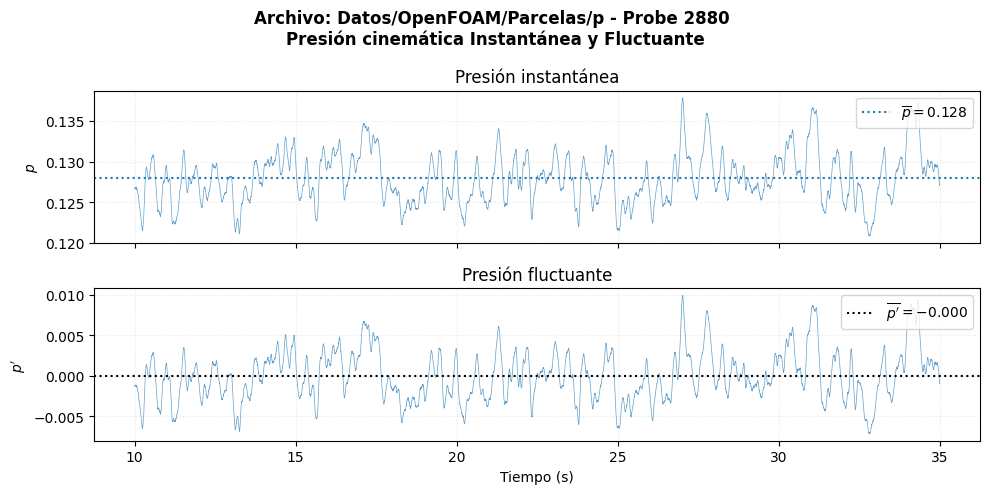

In [4]:
# Probe a visualizar
probe_1 = 2880
# Visualización de señal de presión
p1, t1, _ = imta.recortar_tiempo(p_probes, probe=probe_1, inicio=inicio)
p1_fluc, _ = imta.fluctuante(p1, tiempo=t1)

imta.plot_p(t1, p1_fluc,
            titulo=f'Archivo: {file_p} - Probe {probe_1} \nPresión cinemática Instantánea y Fluctuante',
            etiqueta='p');

In [5]:
# # Proceso de velocidad
# u1_a, u2_a, u3_a, tU_a, dfU_a = imta.recortar_tiempo(U_probes, probe=probe_1, inicio=inicio)
# u1_fluc, _ = imta.fluctuante(u1_a, tiempo=tU_a)
# u2_fluc, _ = imta.fluctuante(u2_a, tiempo=tU_a)
# u3_fluc, _ = imta.fluctuante(u3_a, tiempo=tU_a)

# imta.plot_ui(tU_a, u1_fluc, u2_fluc, u3_fluc,
#             titulo=f'Archivo: {file_U} - Probe {probe_1} \nVelocidades Instantáneas y Fluctuantes',
#             etiquetas=('u_1', 'u_2', 'u_3'));

In [6]:
# Creación de vector con ángulos
angulos_deg = np.arange(0, 360, 10)
angulos_rad = np.radians(angulos_deg) # Conversión a radianes
dtheta = angulos_rad[1]-angulos_rad[0] # Paso de ángulo

num_cil = 80 
allprobes = np.arange(0, num_cil, 1) 

# Iniciar el diccionario vacío
cilindros = {}

for probe_i in allprobes:
    puntos_i = list(range(probe_i * angulos_deg.size, (probe_i + 1) * angulos_deg.size))
    
    # Guardar lista en el diccionario usando probe_i como índice
    cilindros[probe_i] = puntos_i

# Prueba
# print("Puntos del cilindro 1:")
# print(cilindros[0])
# print("Puntos del cilindro -1:")
# print(cilindros[num_cil-1])

In [7]:
# Datos de: p_inf
print('p_inf (media) en cada plano')
print(f'y=0.20: {(np.mean(p_probes[2880])*rho):2f} Pa')
print(f'y=0.40: {(np.mean(p_probes[2881])*rho):2f} Pa')
print(f'y=0.65: {(np.mean(p_probes[2882])*rho):2f} Pa')
print(f'y=1.15: {(np.mean(p_probes[2883])*rho):2f} Pa')

p_inf (media) en cada plano
y=0.20: 131.198502 Pa
y=0.40: 144.513229 Pa
y=0.65: 156.699448 Pa
y=1.15: 171.609543 Pa


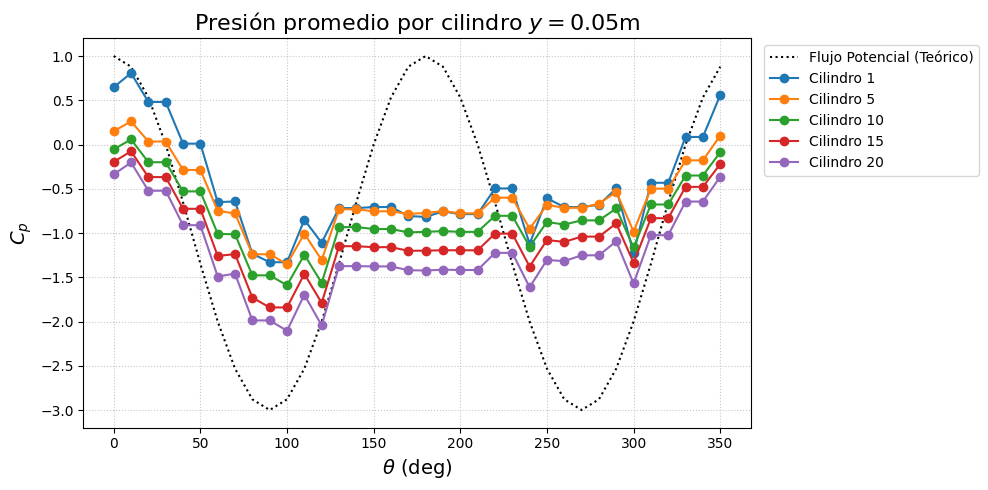

In [8]:
# Plano de 0.020 [Cilindro 1 al 20]
U_inf = 0.530  # m/s
p_inf = 131.198 # Pa

Cp_teorico = 1 - 4 * (np.sin(angulos_rad)**2)

# Declaración de diccionarios
Cp = {}
p_pa = {}

# Ciclo para calcular Cp y p_pa por cada cilindro
for i in cilindros.keys():
    # Uso de función cp_promedio_por_theta
    Cp[i], p_pa[i] = imta.cp_promedio_por_theta(p_probes, cilindros[i], rho, U_inf, p_inf, t_ini=inicio)

# Graficando serie para pada Cp
plt.figure(figsize=(10, 5))

plt.plot(angulos_deg, Cp_teorico, 'k:', linewidth=1.5, label='Flujo Potencial (Teórico)')

# # Para todas probes
# for i in Cp.keys():
#     plt.plot(angulos_deg, Cp[i], '.-', label=f'Cilindro {i+1}')

# Para probes especificas
cilindros_a_graficar = [0, 4, 9, 14, 19] # índices de cilindros a graficar 0=cilindro1, 2=cilindro2, 4=cilindro3
#cilindros_a_graficar = np.linspace(0, 19, 20) # Primeros 20 cilindros

for i in cilindros_a_graficar:
    plt.plot(angulos_deg, Cp[i], 'o-', label=f'Cilindro {i+1}')

plt.xlabel(r'$\theta$ (deg)', fontsize=14)
plt.ylabel(r'$C_p$', fontsize=14)
plt.title(r'Presión promedio por cilindro $y=0.05 \mathrm{m}$', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()

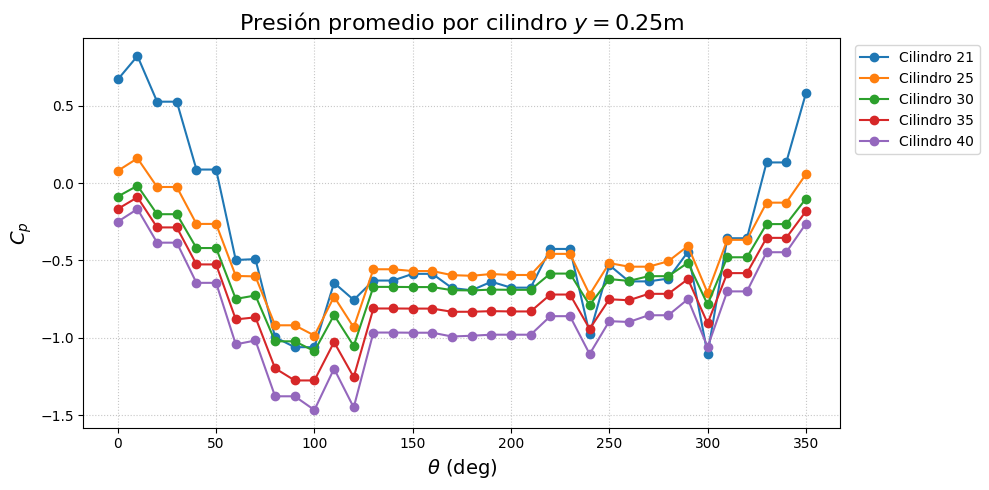

In [9]:
# Plano de 0.040 [Cilindro 21 al 40]
U_inf = 0.671  # m/s
p_inf = 144.51 # Pa

# Declaración de diccionarios
Cp = {}
p_pa = {}

# Ciclo para calcular Cp y p_pa por cada cilindro
for i in cilindros.keys():
    # Uso de función cp_promedio_por_theta
    Cp[i], p_pa[i] = imta.cp_promedio_por_theta(p_probes, cilindros[i], rho, U_inf, p_inf, t_ini=inicio)

# Graficando serie para pada Cp
plt.figure(figsize=(10, 5))

# # Para ver todas las probes
# for i in Cp.keys():
#     plt.plot(angulos_deg, Cp[i], '.-', label=f'Cilindro {i+1}')

# Para probes especificas
cilindros_a_graficar = [20, 24, 29, 34, 39] # índices de cilindros a graficar 0=cilindro1, 2=cilindro2, 4=cilindro3
#cilindros_a_graficar = np.linspace(0, 19, 20) # Primeros 20 cilindros

for i in cilindros_a_graficar:
    plt.plot(angulos_deg, Cp[i], 'o-', label=f'Cilindro {i+1}')

plt.xlabel(r'$\theta$ (deg)', fontsize=14)
plt.ylabel(r'$C_p$', fontsize=14)
plt.title(r'Presión promedio por cilindro $y=0.25 \mathrm{m}$', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()

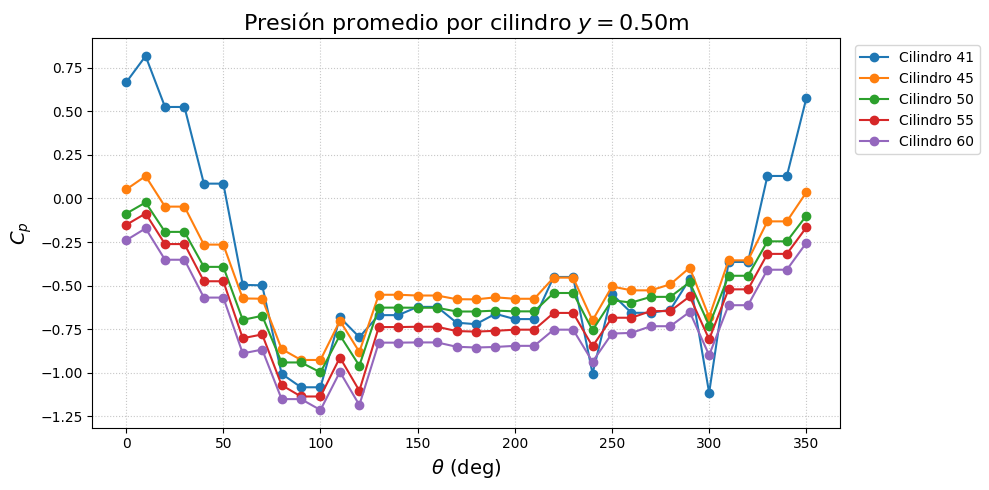

In [10]:
# Plano de 0.50 [Cilindro 41 al 60]
U_inf = 0.742  # m/s
p_inf = 156.694 # Pa

# Declaración de diccionarios
Cp = {}
p_pa = {}

# Ciclo para calcular Cp y p_pa por cada cilindro
for i in cilindros.keys():
    # Uso de función cp_promedio_por_theta
    Cp[i], p_pa[i] = imta.cp_promedio_por_theta(p_probes, cilindros[i], rho, U_inf, p_inf, t_ini=inicio)

# Graficando serie para pada Cp
plt.figure(figsize=(10, 5))

# # Para ver todas las probes
# for i in Cp.keys():
#     plt.plot(angulos_deg, Cp[i], '.-', label=f'Cilindro {i+1}')

# Para probes especificas
cilindros_a_graficar = [40, 44, 49, 54, 59] # índices de cilindros a graficar 0=cilindro1, 2=cilindro2, 4=cilindro3
#cilindros_a_graficar = np.linspace(0, 19, 20) # Primeros 20 cilindros

for i in cilindros_a_graficar:
    plt.plot(angulos_deg, Cp[i], 'o-', label=f'Cilindro {i+1}')

plt.xlabel(r'$\theta$ (deg)', fontsize=14)
plt.ylabel(r'$C_p$', fontsize=14)
plt.title(r'Presión promedio por cilindro $y=0.50 \mathrm{m}$', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()

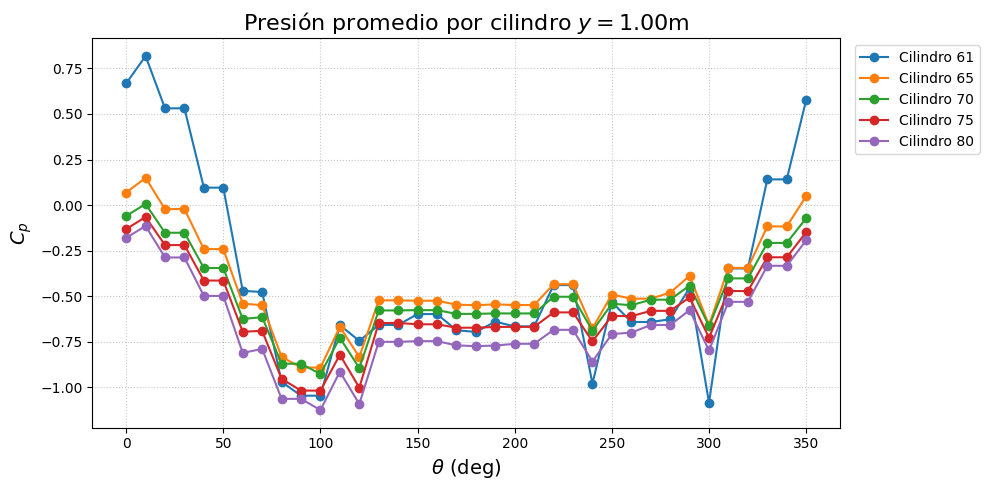

In [11]:
# Plano de 0.50 [Cilindro 61 al 80]
U_inf = 0.820  # m/s
p_inf = 171.609 # Pa

# Declaración de diccionarios
Cp = {}
p_pa = {}

# Ciclo para calcular Cp y p_pa por cada cilindro
for i in cilindros.keys():
    # Uso de función cp_promedio_por_theta
    Cp[i], p_pa[i] = imta.cp_promedio_por_theta(p_probes, cilindros[i], rho, U_inf, p_inf, t_ini=inicio)

# Graficando serie para pada Cp
plt.figure(figsize=(10, 5))

# # Para ver todas las probes
# for i in Cp.keys():
#     plt.plot(angulos_deg, Cp[i], '.-', label=f'Cilindro {i+1}')

# Para probes especificas
cilindros_a_graficar = [60, 64, 69, 74, 79] # índices de cilindros a graficar 0=cilindro1, 2=cilindro2, 4=cilindro3
#cilindros_a_graficar = np.linspace(0, 19, 20) # Primeros 20 cilindros

for i in cilindros_a_graficar:
    plt.plot(angulos_deg, Cp[i], 'o-', label=f'Cilindro {i+1}')

plt.xlabel(r'$\theta$ (deg)', fontsize=14)
plt.ylabel(r'$C_p$', fontsize=14)
plt.title(r'Presión promedio por cilindro $y=1.00 \mathrm{m}$', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()

Cilindro          Fd_mean (N)    Fl_mean (N)    CD_mean    CL_mean
----------------------------------------------------------------
Cilindro 1          -3.489616       0.327097   -0.82820    0.07763
Cilindro 5          -2.384944       0.742458   -0.56602    0.17621
Cilindro 10         -2.403580       0.936436   -0.57045    0.22225
Cilindro 15         -2.608009       1.134389   -0.61896    0.26923
Cilindro 20         -2.822606       1.154952   -0.66990    0.27411


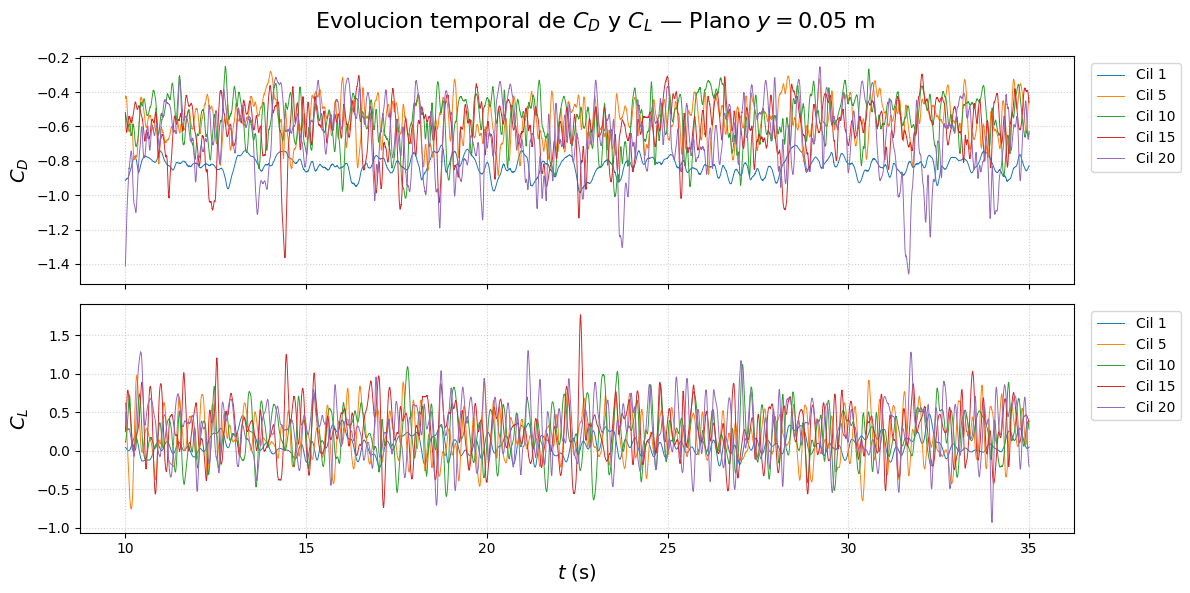

In [ ]:
import numpy as np
# Función para extraer presión por cilindro
def extraer_p_theta(p_probes, probes_ordenados, t_inicio=0.0):
    """
    Extrae y apila las series temporales de presion cinematica (m^2/s^2)
    de un conjunto de probes ordenadas angularmente.

    Parametros
    ----------
    p_probes : dict
        Diccionario de Series de presion por probe (formato de cargar_p_OpenFOAM).
    probes_ordenados : list of int
        Indices de sondas en orden angular creciente.
    t_inicio : float, opcional
        Instante inicial para el recorte temporal (s). Por defecto 50.0.

    Retorna
    -------
    p_theta : numpy.ndarray, forma (n_tiempos, n_angulos)
        Matriz de presion cinematica (m^2/s^2).
    tiempo : numpy.ndarray
        Vector de tiempo recortado (s).
    """
    series_p = []
    for prb in probes_ordenados:
        p_i, t_i, _ = imta.recortar_tiempo(
            p_probes, probe=prb,
            inicio=t_inicio
        )
        series_p.append(p_i.values)

    p_theta = np.vstack(series_p).T  # (n_tiempos, n_angulos)
    return p_theta, t_i.values


# Función para CD y CL a partir de presión cinematica
def cd_cl_integrando_p(p_theta, theta, rho, U_inf, R, D, span):
    """
    Calcula las series temporales de los coeficientes de arrastre (CD)
    y sustentacion (CL) por integracion de presion sobre la superficie
    de un cilindro.

    Parametros
    ----------
    p_theta : numpy.ndarray, forma (n_tiempos, n_angulos)
        Presion cinematica (m^2/s^2) en cada instante y posicion angular.
    theta : numpy.ndarray
        Vector de angulos en radianes.
    rho : float
        Densidad del fluido (kg/m^3).
    U_inf : float
        Velocidad de corriente libre (m/s).
    R : float
        Radio del cilindro (m).
    D : float
        Diametro del cilindro (m).
    span : float
        Altura (envergadura) del cilindro (m).

    Retorna
    -------
    CD : numpy.ndarray
        Serie temporal del coeficiente de arrastre.
    CL : numpy.ndarray
        Serie temporal del coeficiente de sustentacion.
    """
    dtheta = theta[1] - theta[0]
    p_pa = rho * p_theta
    nx = np.cos(theta)
    nz = np.sin(theta)

    # Fuerzas por unidad de longitud (N/m)
    Fx = -np.sum(p_pa * nx, axis=1) * R * dtheta
    Fz = -np.sum(p_pa * nz, axis=1) * R * dtheta

    # Fuerza total 3D
    Fx_total = Fx * span
    Fz_total = Fz * span

    # Coeficientes
    A = D * span
    q = 0.5 * rho * U_inf**2
    CD = Fx_total / (q * A)
    CL = Fz_total / (q * A)

    return CD, CL, Fx_total, Fz_total


# === Parametros ===
U_inf = 0.530   # m/s
D = 0.03        # m
R = D / 2       # m
span = 1.00     # m (altura de la pila)
angulos_rad = np.deg2rad(angulos_deg)

# === Extraer presion y calcular CD, CL por cada cilindro ===
CD = {}
CL = {}
Fx = {}
Fz = {}
p_theta_dict = {}
tiempo_cd = None

for i in cilindros.keys():
    p_theta_i, t_i = extraer_p_theta(p_probes, cilindros[i], t_inicio=inicio)
    p_theta_dict[i] = p_theta_i
    CD[i], CL[i], Fx[i], Fz[i] = cd_cl_integrando_p(p_theta_i, angulos_rad, rho, U_inf, R, D, span)
    if tiempo_cd is None:
        tiempo_cd = t_i

# === Graficas de CD y CL para cilindros seleccionados ===
cilindros_a_graficar = [0, 4, 9, 14, 19]
#cilindros_a_graficar = [0,1]
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

print(f"{'Cilindro':<14} {'Fd_mean (N)':>14} {'Fl_mean (N)':>14} {'CD_mean':>10} {'CL_mean':>10}")
print("-" * 64)

for i in cilindros_a_graficar:
    ax[0].plot(tiempo_cd, CD[i], linewidth=0.7, label=f'Cil {i+1}')
    ax[1].plot(tiempo_cd, CL[i], linewidth=0.7, label=f'Cil {i+1}')
    print(f"{'Cilindro ' + str(i+1):<14} "
    f"{np.mean(Fx[i]):>14.6f} "
    f"{np.mean(Fz[i]):>14.6f} "
    f"{np.mean(CD[i]):>10.5f} "
    f"{np.mean(CL[i]):>10.5f}")

# Panel superior: CD
ax[0].set_ylabel(r'$C_D$', fontsize=14)
ax[0].grid(True, linestyle=':', alpha=0.6)
ax[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left')

# Panel inferior: CL
ax[1].set_ylabel(r'$C_L$', fontsize=14)
ax[1].set_xlabel(r'$t$ (s)', fontsize=14)
ax[1].grid(True, linestyle=':', alpha=0.6)
ax[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle(r'Evolucion temporal de $C_D$ y $C_L$ — Plano $y=0.05$ m', fontsize=16)
plt.tight_layout()

<img src="./Datos/Imagenes/Fd_Fl.png" height="200" align="middle">